In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

df = pd.read_csv("housing.csv")
df.head()
df.isna().mean()*100
df["total_rooms"].median()

2127.0

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [3]:
df.head(10)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY
7,-122.25,37.84,52.0,3104.0,687.0,1157.0,647.0,3.1200,241400.0,NEAR BAY
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,NEAR BAY
9,-122.25,37.84,52.0,3549.0,707.0,1551.0,714.0,3.6912,261100.0,NEAR BAY


In [4]:
X = df.drop(columns="median_house_value")
y = df["median_house_value"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size= .2, random_state= 42
)


In [5]:
df.corr(numeric_only=True)["median_house_value"]

longitude            -0.045967
latitude             -0.144160
housing_median_age    0.105623
total_rooms           0.134153
total_bedrooms        0.049686
population           -0.024650
households            0.065843
median_income         0.688075
median_house_value    1.000000
Name: median_house_value, dtype: float64

<Axes: xlabel='total_bedrooms'>

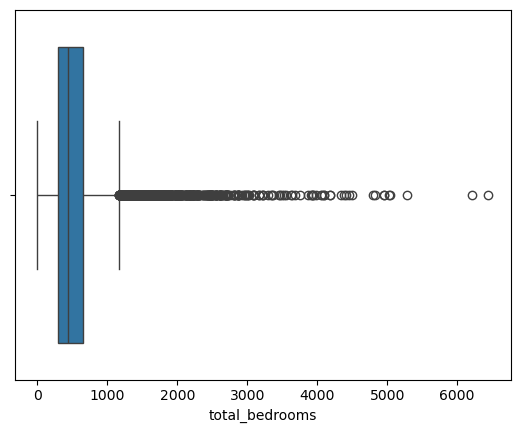

In [6]:
import seaborn as sns

sns.boxplot(x = X_train["total_bedrooms"])

In [7]:
X_train.isna().sum()
print(X_train.columns)
X_test.isna().sum()
X_train.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'ocean_proximity'],
      dtype='object')


Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'ocean_proximity'],
      dtype='object')

In [8]:
X_train

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
14196,-117.03,32.71,33.0,3126.0,627.0,2300.0,623.0,3.2596,NEAR OCEAN
8267,-118.16,33.77,49.0,3382.0,787.0,1314.0,756.0,3.8125,NEAR OCEAN
17445,-120.48,34.66,4.0,1897.0,331.0,915.0,336.0,4.1563,NEAR OCEAN
14265,-117.11,32.69,36.0,1421.0,367.0,1418.0,355.0,1.9425,NEAR OCEAN
2271,-119.80,36.78,43.0,2382.0,431.0,874.0,380.0,3.5542,INLAND
...,...,...,...,...,...,...,...,...,...
11284,-117.96,33.78,35.0,1330.0,201.0,658.0,217.0,6.3700,<1H OCEAN
11964,-117.43,34.02,33.0,3084.0,570.0,1753.0,449.0,3.0500,INLAND
5390,-118.38,34.03,36.0,2101.0,569.0,1756.0,527.0,2.9344,<1H OCEAN
860,-121.96,37.58,15.0,3575.0,597.0,1777.0,559.0,5.7192,<1H OCEAN


In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

numeric_columns = [
    "longitude",
    "latitude",
    "housing_median_age",
    "total_rooms",
    "population",
    "households",
    "median_income"
]

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, numeric_columns),
    ("cat", OneHotEncoder(handle_unknown="ignore"), ["ocean_proximity"])
])

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

model = Pipeline([
    ("preprocess", preprocessor),
    ("poly", PolynomialFeatures(degree=2)),
    ("lr", LinearRegression())
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [11]:
from sklearn.metrics import r2_score

print("R2 score:", r2_score(y_test, y_pred))

R2 score: 0.6924899962188475


In [12]:
from sklearn.linear_model import RidgeCV

ridge_model = Pipeline([
    ("preprocess", preprocessor),
    ("poly", PolynomialFeatures(degree=2)),
    ("lr", RidgeCV(
        cv = 5
    ))
])

ridge_model.fit(X_train, y_train)
y_pred = ridge_model.predict(X_test)
print("R2 score:", r2_score(y_test, y_pred))

R2 score: 0.6929619490438059


In [13]:
from sklearn.linear_model import LassoCV

lasso_model = Pipeline([
    ("preprocess", preprocessor),
    ("poly", PolynomialFeatures(degree=2)),
    ("lr", LassoCV(
        cv = 5,
        max_iter= 10000,
        random_state = 42
    ))
])

lasso_model.fit(X_train, y_train)
y_pred = lasso_model.predict(X_test)
print("R2 score:", r2_score(y_test, y_pred))

R2 score: 0.6700266872038794


In [14]:
X_train.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
14196,-117.03,32.71,33.0,3126.0,627.0,2300.0,623.0,3.2596,NEAR OCEAN
8267,-118.16,33.77,49.0,3382.0,787.0,1314.0,756.0,3.8125,NEAR OCEAN
17445,-120.48,34.66,4.0,1897.0,331.0,915.0,336.0,4.1563,NEAR OCEAN
14265,-117.11,32.69,36.0,1421.0,367.0,1418.0,355.0,1.9425,NEAR OCEAN
2271,-119.80,36.78,43.0,2382.0,431.0,874.0,380.0,3.5542,INLAND


In [15]:
X["house_age_group"] = pd.cut(
    X["housing_median_age"],
    bins=[0, 10, 20, 30, 40, 50],
    labels=["new", "young", "mid", "old", "very_old"]
)

In [16]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size= .2, random_state= 42
)
X_train

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,house_age_group
14196,-117.03,32.71,33.0,3126.0,627.0,2300.0,623.0,3.2596,NEAR OCEAN,old
8267,-118.16,33.77,49.0,3382.0,787.0,1314.0,756.0,3.8125,NEAR OCEAN,very_old
17445,-120.48,34.66,4.0,1897.0,331.0,915.0,336.0,4.1563,NEAR OCEAN,new
14265,-117.11,32.69,36.0,1421.0,367.0,1418.0,355.0,1.9425,NEAR OCEAN,old
2271,-119.80,36.78,43.0,2382.0,431.0,874.0,380.0,3.5542,INLAND,very_old
...,...,...,...,...,...,...,...,...,...,...
11284,-117.96,33.78,35.0,1330.0,201.0,658.0,217.0,6.3700,<1H OCEAN,old
11964,-117.43,34.02,33.0,3084.0,570.0,1753.0,449.0,3.0500,INLAND,old
5390,-118.38,34.03,36.0,2101.0,569.0,1756.0,527.0,2.9344,<1H OCEAN,old
860,-121.96,37.58,15.0,3575.0,597.0,1777.0,559.0,5.7192,<1H OCEAN,young


In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder,OrdinalEncoder
from sklearn.pipeline import Pipeline

numeric_columns = [
    "longitude",
    "latitude",
    "housing_median_age",
    "total_rooms",
    "population",
    "households",
    "median_income"
]

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

ordinal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(
        categories=[["new", "young", "mid", "old", "very_old"]]
    ))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, numeric_columns),
    ("cat_encoder", ordinal_pipeline, ["house_age_group"]),
    ("cat", OneHotEncoder(handle_unknown="ignore"), ["ocean_proximity"])
])

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

model = Pipeline([
    ("preprocess", preprocessor),
    ("poly", PolynomialFeatures(degree=2)),
    ("lr", LinearRegression())
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

score = r2_score(y_test, y_pred)
score

0.6950501035169178

In [18]:
X_train["house_age_group"].isna().sum()

np.int64(1057)

In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder,OrdinalEncoder
from sklearn.pipeline import Pipeline

numeric_columns = [
    "longitude",
    "latitude",
    "housing_median_age",
    "total_rooms",
    "population",
    "households",
    "median_income"
]

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

ordinal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(
        categories=[["new", "young", "mid", "old", "very_old"]]
    ))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, numeric_columns),
    ("cat_encoder", ordinal_pipeline, ["house_age_group"]),
    ("cat", OneHotEncoder(handle_unknown="ignore"), ["ocean_proximity"])
])

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

lasso_model = Pipeline([
    ("preprocess", preprocessor),
    ("poly", PolynomialFeatures(degree=2)),
    ("lr", LassoCV(
        cv = 5, 
        max_iter= 10000,
        random_state=42
    ))
])

lasso_model.fit(X_train, y_train)
y_pred = lasso_model.predict(X_test)

from sklearn.metrics import r2_score

r2_score = r2_score(y_test, y_pred)
r2_score

0.6626823774348662

In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder,OrdinalEncoder
from sklearn.pipeline import Pipeline

numeric_columns = [
    "longitude",
    "latitude",
    "housing_median_age",
    "total_rooms",
    "population",
    "households",
    "median_income"
]

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

ordinal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(
        categories=[["new", "young", "mid", "old", "very_old"]]
    ))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, numeric_columns),
    ("cat_encoder", ordinal_pipeline, ["house_age_group"]),
    ("cat", OneHotEncoder(handle_unknown="ignore"), ["ocean_proximity"])
])

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

ridge_model = Pipeline([
    ("preprocess", preprocessor),
    ("poly", PolynomialFeatures(degree=2)),
    ("ridge", RidgeCV(
        cv = 5
    ))
])

ridge_model.fit(X_train, y_train)
y_pred = ridge_model.predict(X_test)

from sklearn.metrics import r2_score

r2_score = r2_score(y_test, y_pred)
r2_score

0.6955244975818061

In [21]:
df.corr(numeric_only=True)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924664,-0.108197,0.044568,0.069608,0.099773,0.055310,-0.015176,-0.045967
latitude,-0.924664,1.000000,0.011173,-0.036100,-0.066983,-0.108785,-0.071035,-0.079809,-0.144160
housing_median_age,-0.108197,0.011173,1.000000,-0.361262,-0.320451,-0.296244,-0.302916,-0.119034,0.105623
total_rooms,0.044568,-0.036100,-0.361262,1.000000,0.930380,0.857126,0.918484,0.198050,0.134153
total_bedrooms,0.069608,-0.066983,-0.320451,0.930380,1.000000,0.877747,0.979728,-0.007723,0.049686
population,0.099773,-0.108785,-0.296244,0.857126,0.877747,1.000000,0.907222,0.004834,-0.024650
households,0.055310,-0.071035,-0.302916,0.918484,0.979728,0.907222,1.000000,0.013033,0.065843
median_income,-0.015176,-0.079809,-0.119034,0.198050,-0.007723,0.004834,0.013033,1.000000,0.688075
median_house_value,-0.045967,-0.144160,0.105623,0.134153,0.049686,-0.024650,0.065843,0.688075,1.000000


In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder,OrdinalEncoder
from sklearn.pipeline import Pipeline

numeric_columns = [
    "longitude",
    "population",
    "households"
]

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

ordinal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(
        categories=[["new", "young", "mid", "old", "very_old"]]
    ))
])
poly_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=2, include_bias=False))
])

preprocessor = ColumnTransformer([
     ("poly_num", poly_pipeline, ["latitude", "housing_median_age", "total_rooms", "median_income"]),
    ("num", num_pipeline, numeric_columns),
    ("cat_encoder", ordinal_pipeline, ["house_age_group"]),
    ("cat", OneHotEncoder(handle_unknown="ignore"), ["ocean_proximity"])
])

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

ridge_model = Pipeline([
    ("preprocess", preprocessor),
    ("ridge", RidgeCV(
        cv = 5
    ))
])

ridge_model.fit(X_train, y_train)
y_pred = ridge_model.predict(X_test)

from sklearn.metrics import r2_score

score = r2_score(y_test, y_pred)
score

0.6454539899197224

In [23]:
model = Pipeline([
    ("preprocess", preprocessor),
    ("lr", LinearRegression())
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

from sklearn.metrics import r2_score

score = r2_score(y_test, y_pred)
score

0.6455310293067344